# Exercise

In [8]:
# You can add any other libraries you would like
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm, trange
from time import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Step 1: Dataset

In this exercise, we want to train an MLP on CIFAR10 dataset and plan to reach a reasonable accuracy

Step 1 is to load the dataset

In [9]:
# TODO: Define transformations to normalize the dataset
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2023, 0.1994, 0.2010]

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean,std),
    # transforms.GaussianBlur((5, 5))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
# TODO: Download the training and test datasets
downloaded_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
downloaded_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
## EXTRA include a validation set
train_size = int(len(downloaded_train) * 0.8)
validation_size = len(downloaded_train) - train_size
train_data, validation_data = random_split(downloaded_train, [train_size, validation_size])
# TODO: Wrap them in DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=256, shuffle=False)
test_loader = DataLoader(downloaded_test, batch_size=256, shuffle=False)


When working with a new dataset, it is always a good idea to visualize the data and print some information about it.

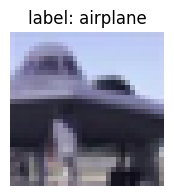

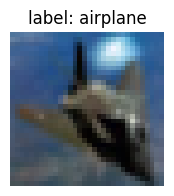

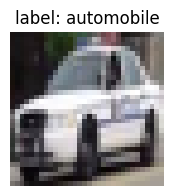

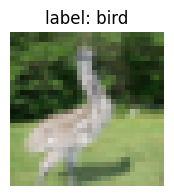

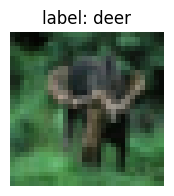

In [10]:
classes = downloaded_train.classes
def imshow(img, label, pred=None, c=classes):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    img = img * std + mean
    npimg = img.numpy().transpose((1, 2, 0))
    plt.figure(figsize=(2, 2))
    plt.imshow(np.clip(npimg, 0, 1))
    if pred is not None:
        plt.title(f"label: {c[label]}, pred: {c[pred]}")
    else:
        plt.title(f"label: {c[label]}")
    plt.axis("off")
    plt.show()

# TODO: Show images
for images, labels in train_loader:
    for idx in range(5):
        # image = images[idx]
        # label = labels[idx]
        # print(image.shape)
        imshow(images[idx], labels[idx])
    break

## Model

In [11]:
# TODO: define model
class BaseLine(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(3, 64, 5, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),# 14 * 14
            nn.Conv2d(64, 32, 3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 7 * 7
            nn.Conv2d(32, 32, 3, padding="same"),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(8),
            nn.Flatten(),
            nn.Linear(32*8*8, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
            )

    def forward(self, x):
        return self.sequential(x)

In [23]:
# TODO: define model
class BN_DO_AF(nn.Module): #batch norm + drop out + activation function
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(3, 64, 5, padding="same", bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2, 2),# 14 * 14
            nn.Conv2d(64, 32, 3, padding="same", bias=False),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2, 2), # 7 * 7
            nn.Conv2d(32, 32, 3,padding="same", bias=False),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.AdaptiveAvgPool2d(8),
            nn.Flatten(),
            nn.Linear(32*8*8, 32, False),
            nn.BatchNorm1d(32),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 10)
            )

    def forward(self, x):
        return self.sequential(x)

## Train

In [14]:
bl_model = BaseLine().to(device)

# TODO: choose a loss function and an optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(bl_model.parameters(), lr = 1e-3, momentum=0.99, weight_decay=1e-5, nesterov=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4)

In [25]:
def train_model(model, epochs):
    list_train_losses = []
    list_validation_losses = []
    list_avg_val, list_avg_train = [], []
    print(optimizer)

    for epoch in trange(epochs, leave=True):
        start = time() # at first this was outside of loop
        epoch_train_loss = 0
        epoch_validation_loss = 0
        list_train_preds, list_val_preds = [], []
        list_train_gt, list_val_gt = [], []
        # TODO: Complete the training loop

        model.train()
        for x_train, y_train in tqdm(train_loader, leave=False):
            x_train = x_train.to(device)
            y_train = y_train.to(device)
            train_preds = model(x_train)
            train_loss = criterion(train_preds, y_train)
            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()
            list_train_losses.append(train_loss.item())
            epoch_train_loss += train_loss.item() * x_train.size(0)
            list_train_preds.extend(train_preds.argmax(-1).detach().cpu().numpy())
            list_train_gt.extend(y_train.detach().cpu().numpy())



        model.eval()
        with torch.inference_mode():
            for x_validation, y_validation in tqdm(validation_loader, leave=False):
                x_validation = x_validation.to(device)
                y_validation = y_validation.to(device)
                validation_preds = model(x_validation)
                validation_loss = criterion(validation_preds, y_validation)
                list_validation_losses.append(validation_loss.item())
                epoch_validation_loss += validation_loss.item() * x_validation.size(0)
                list_val_preds.extend(validation_preds.argmax(-1).detach().cpu().numpy())
                list_val_gt.extend(y_validation.detach().cpu().numpy())

        average_train_loss = epoch_train_loss / len(train_loader.dataset)
        average_validation_loss = epoch_validation_loss / len(validation_loader.dataset)
        list_avg_val.append(average_validation_loss)
        list_avg_train.append(average_train_loss)
        scheduler.step(average_validation_loss)
        val_f1 = f1_score(list_val_gt, list_val_preds, average="macro")
        train_f1 = f1_score(list_train_gt, list_train_preds, average="macro")
        val_acc = accuracy_score(list_val_gt, list_val_preds)
        train_acc = accuracy_score(list_train_gt, list_train_preds)
        print(f"train[ accuracy: {train_acc:.4f}, f1: {train_f1:.4f} ] | val[ accuracy: {val_acc:.4f}, f1: {val_f1:.4f} ] | took {time() - start}")
    return model, list_train_losses, list_validation_losses, list_avg_train, list_avg_val

In [17]:
trained_bl_model, list_train_losses, list_validation_losses, list_avg_train, list_avg_val = train_model(bl_model, 50)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.99
    nesterov: True
    weight_decay: 1e-05
)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

train[ accuracy: 0.4087, f1: 0.4040 ] | val[ accuracy: 0.5325, f1: 0.5220 ] | took 18.291821241378784


...

  0%|          | 0/40 [00:00<?, ?it/s]

train[ accuracy: 0.9343, f1: 0.9343 ] | val[ accuracy: 0.7087, f1: 0.7070 ] | took 860.0711283683777


  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

train[ accuracy: 0.9343, f1: 0.9343 ] | val[ accuracy: 0.7087, f1: 0.7070 ] | took 877.2410845756531


## Evaluation

In [18]:
def test_model(model):
    accuracy = 0
    # TODO: Prepare for the loop
    with torch.no_grad():
        # TODO: Complete the test loop
        for x_test, y_test in test_loader:
            x_test = x_test.to(device)
            y_test = y_test.to(device)
            test_preds = model(x_test).argmax(-1)
            accuracy += ((y_test == test_preds).long()).sum()
    final_accuracy = accuracy / len(test_loader.dataset)
    print(f"Accuracy on test set: {final_accuracy:.4f}%")
test_model(trained_bl_model)

Accuracy on test set: 0.7184%


### Visualization

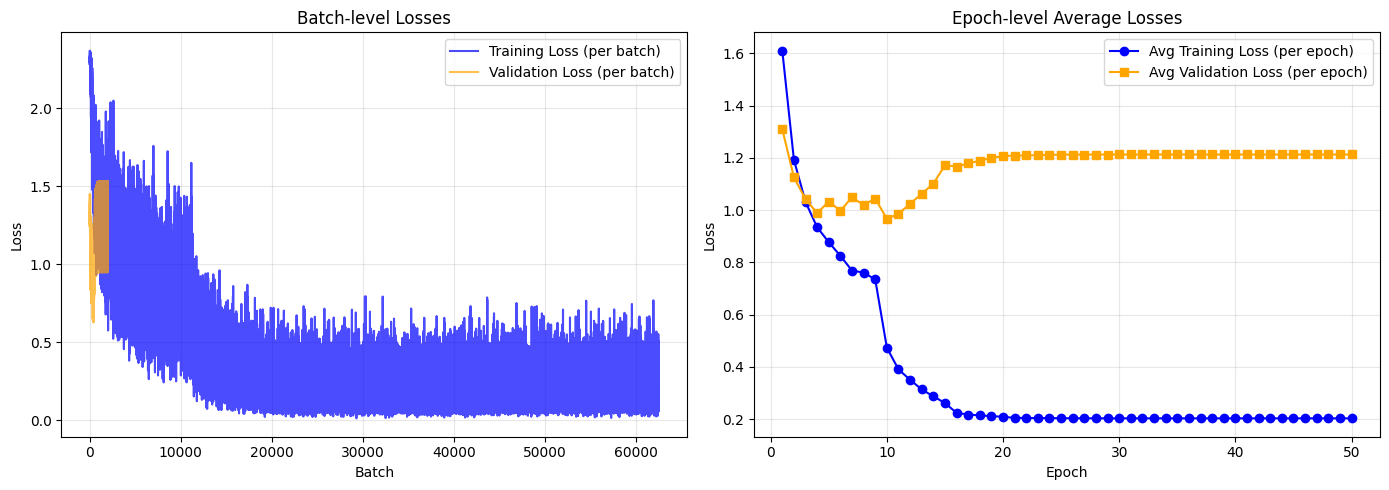

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_training_progress(list_train_losses, list_validation_losses, list_avg_train, list_avg_val):
    """
    Creates two subplots:
    1. Batch-level training and validation losses
    2. Epoch-level average training and validation losses
    """

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # --- 1. Batch-level losses ---
    axs[0].plot(range(1, len(list_train_losses) + 1), list_train_losses,
                label='Training Loss (per batch)', color='blue', alpha=0.7)
    axs[0].plot(range(1, len(list_validation_losses) + 1), list_validation_losses,
                label='Validation Loss (per batch)', color='orange', alpha=0.7)
    axs[0].set_title('Batch-level Losses')
    axs[0].set_xlabel('Batch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # --- 2. Epoch-level average losses ---
    epochs = range(1, len(list_avg_train) + 1)
    axs[1].plot(epochs, list_avg_train, marker='o', label='Avg Training Loss (per epoch)', color='blue')
    axs[1].plot(epochs, list_avg_val, marker='s', label='Avg Validation Loss (per epoch)', color='orange')
    axs[1].set_title('Epoch-level Average Losses')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
visualize_training_progress(list_train_losses, list_validation_losses, list_avg_train, list_avg_val)

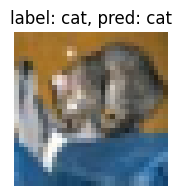

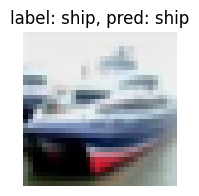

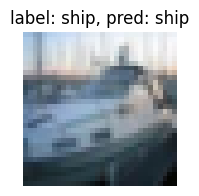

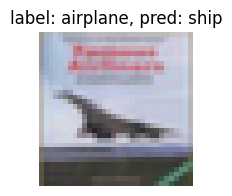

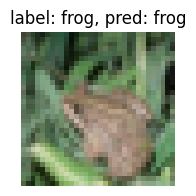

In [21]:
# TODO: Visualize some images with their true label and their predicted label
def Visualize(model, n_pic=5):
    with torch.no_grad():
        for x_test, y_test in test_loader:

            x_test = x_test.to(device)
            y_test = y_test.to(device)
            test_preds = model(x_test).argmax(-1)
            for i in range(n_pic):
                imshow(x_test[i].detach().cpu(), y_test[i].detach().cpu(), test_preds[i].detach().cpu())
            break
Visualize(trained_bl_model)

In [27]:
ad_model = BN_DO_AF().to(device)

# TODO: choose a loss function and an optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(ad_model.parameters(), lr = 1e-2, weight_decay=1e-5, amsgrad=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

trained_advanced_model, list_train_losses, list_validation_losses, list_avg_train, list_avg_val = train_model(ad_model, 50)

AdamW (
Parameter Group 0
    amsgrad: True
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 1e-05
)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

train[ accuracy: 0.4545, f1: 0.4502 ] | val[ accuracy: 0.3368, f1: 0.3097 ] | took 18.433860301971436


...

  0%|          | 0/40 [00:00<?, ?it/s]

train[ accuracy: 0.7964, f1: 0.7964 ] | val[ accuracy: 0.7041, f1: 0.7071 ] | took 18.612694025039673


  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

train[ accuracy: 0.7979, f1: 0.7979 ] | val[ accuracy: 0.6863, f1: 0.6888 ] | took 19.116617679595947


In [28]:
test_model(trained_advanced_model)

Accuracy on test set: 0.6949%


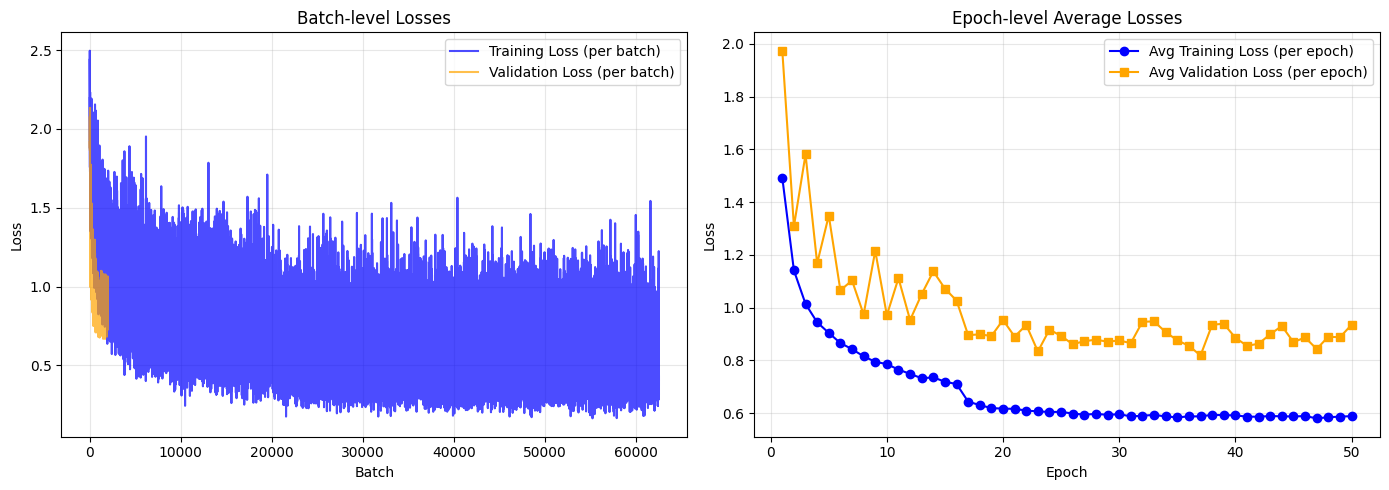

In [29]:
visualize_training_progress(list_train_losses, list_validation_losses, list_avg_train, list_avg_val)

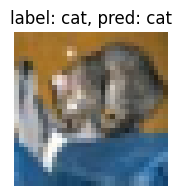

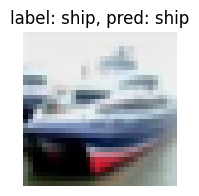

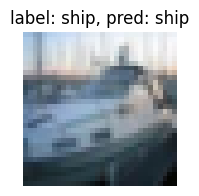

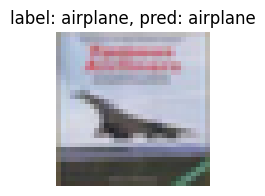

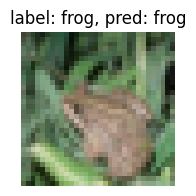

In [30]:
Visualize(trained_advanced_model)